# Demo: 2D image RI2FL

> 2D RI2FL demo


In [1]:
#| default_exp demo

In [2]:
#| hide
from nbdev.showdoc import *

In [3]:
from bioMONAI.data import *
from bioMONAI.transforms import *
from fastai.vision.all import *
from monai.utils import set_determinism
set_determinism(0)
# from sklearn.model_selection import train_test_split

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


### Data

In [5]:
bs, size = 8, 256
# arch = models.resnet34
path = Path('../../bioMONAI_0/_data/Thunder_20230308/nuevos_datos/dataset')
#path = Path('../_data/Babesia/')
path_x = path/'inputs'
path_y = path/'targets'


In [6]:
from bioMONAI.core import get_target
get_target(path_y, same_filename=True)(path / '1.tiff')

Path('../../bioMONAI_0/_data/Thunder_20230308/nuevos_datos/dataset/targets/1.tiff')

### Look at training data

In [7]:
from monai.transforms import ScaleIntensity
item_tfms = [ScaleIntensity(minv=0.0, maxv=1.0),
             RandCropND(size),              
             ]

Setting-up type transforms pipelines
Found 28 items
2 datasets of sizes 23,5
Setting up Pipeline: BioImageProject.create
Setting up Pipeline: get_target.<locals>.generate_target_path -> BioImage.create

Building one sample
  Pipeline: BioImageProject.create
    starting from
      ../../bioMONAI_0/_data/Thunder_20230308/nuevos_datos/dataset/inputs/sample_26.png
    applying BioImageProject.create gives
      BioImageProject of size 1x2048x2048
  Pipeline: get_target.<locals>.generate_target_path -> BioImage.create
    starting from
      ../../bioMONAI_0/_data/Thunder_20230308/nuevos_datos/dataset/inputs/sample_26.png
    applying get_target.<locals>.generate_target_path gives
      ../../bioMONAI_0/_data/Thunder_20230308/nuevos_datos/dataset/targets/sample_26.png
    applying BioImage.create gives
      BioImage of size 1x2048x2048

Final sample: (BioImage([[[59., 61., 57.,  ..., 73., 63., 68.],
         [59., 57., 49.,  ..., 67., 70., 70.],
         [54., 51., 45.,  ..., 70., 73., 74

Setting affine, but the applied meta contains an affine. This will be overwritten.



Building one batch
Applying item_tfms to the first sample:
  Pipeline: ScaleIntensity -> RandCropND -- {'size': (256, 256, 256), 'lazy': False, 'p': 1.0} -> ToTensor
    starting from
      (BioImageProject of size 1x2048x2048, BioImage of size 1x2048x2048)
    applying ScaleIntensity gives
      (MetaTensor of size 1x2048x2048, MetaTensor of size 1x2048x2048)
    applying RandCropND -- {'size': (256, 256, 256), 'lazy': False, 'p': 1.0} gives
      (MetaTensor of size 1x256x256, MetaTensor of size 1x256x256)
    applying ToTensor gives
      (MetaTensor of size 1x256x256, MetaTensor of size 1x256x256)

Adding the next 3 samples

No before_batch transform to apply

Collating items in a batch

Applying batch_tfms to the batch built
  Pipeline: Tensor2BioImage -- {}
    starting from
      (MetaTensor of size 4x1x256x256, MetaTensor of size 4x1x256x256)
    applying Tensor2BioImage -- {} gives
      (BioImage of size 4x1x256x256, BioImage of size 4x1x256x256)


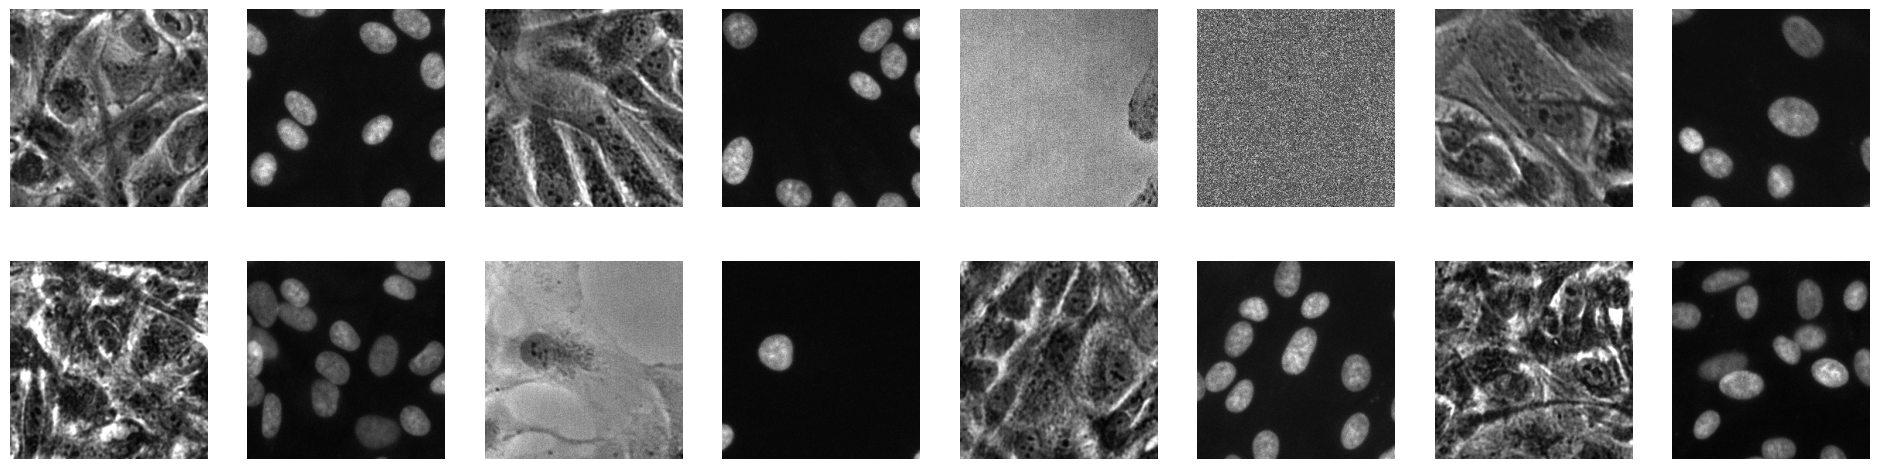

In [8]:
from bioMONAI.core import get_target

dblock = DataBlock(blocks=(BioImageBlock(cls=BioImageProject), BioImageBlock(cls=BioImage)),
                   get_items=get_image_files,
                   get_y=get_target(path_y, same_filename=True),
                   splitter=RandomSplitter(valid_pct=0.2),
                   item_tfms=item_tfms,
                  )

dblock.summary(path_x)

dls = dblock.dataloaders(path_x, bs=bs)
dls.show_batch(max_n=8, cmap='gray')




In [9]:
# training and validation
len(dls.train_ds.items), len(dls.valid_ds.items)

(23, 5)

### Create and train a 2D model

In [10]:
from monai.networks.nets import BasicUNet, AttentionUnet, DynUNet, UNet, BasicUNet
from bioMONAI.nets import DnCNN

In [11]:
# model = UNet(spatial_dims=2, in_channels=1, out_channels=1, channels=(16, 32, 64, 128, 256),strides=(2, 2, 2, 2), num_res_units=2).model
#model = UNet(spatial_dims=3, in_channels=1, out_channels=1, channels=(32, 64, 128, 256),strides=(1, 2, 2), num_res_units=2).model
# model = AttentionUnet(spatial_dims=2, in_channels=1, out_channels=1, channels=(16, 32, 64),strides=(1, 1))
#model = DynUNet(spatial_dims=2, in_channels=1, out_channels=1, strides=(1, 2, 2),kernel_size=(3, 3, 3), upsample_kernel_size=(2, 2), res_block=True) # it tends to create hot pixels
model = BasicUNet(spatial_dims=2, in_channels=1, out_channels=1)



BasicUNet features: (32, 32, 64, 128, 256, 32).


In [12]:
from bioMONAI.losses import CombinedLoss
loss_func = mse #CombinedLoss()

In [13]:
from bioMONAI.losses import SSIMMetric

metrics = [mae, mse, SSIMMetric]

In [14]:
# learn = Learner(dls, model, loss_func=loss_func, opt_func=ranger, metrics=nn.L1Loss)

learn = Learner(dls, model, loss_func=loss_func, metrics=metrics, cbs=ShowGraphCallback())

In [15]:
learn.summary()

BasicUNet (Input shape: 8 x 1 x 256 x 256)
Layer (type)         Output Shape         Param #    Trainable 
                     8 x 32 x 256 x 256  
Conv2d                                    320        True      
InstanceNorm2d                            64         True      
Dropout                                                        
LeakyReLU                                                      
Conv2d                                    9248       True      
InstanceNorm2d                            64         True      
Dropout                                                        
LeakyReLU                                                      
____________________________________________________________________________
                     8 x 32 x 128 x 128  
MaxPool2d                                                      
Conv2d                                    9248       True      
InstanceNorm2d                            64         True      
Dropout                     

SuggestedLRs(valley=0.0008317637839354575)


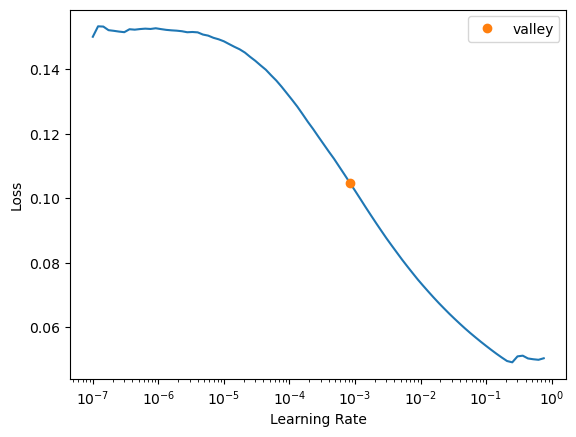

In [16]:
# lr = learn.lr_find(suggest_funcs=(minimum, steep, valley, slide))
lr = learn.lr_find(suggest_funcs=(valley))
print(lr)

In [17]:
lr = float('%.1g'%(lr))
print(lr)

0.0008


epoch,train_loss,valid_loss,mae,mse,SSIM,time
0,0.177868,0.069563,0.199388,0.069563,0.006697,00:02
1,0.123711,0.058590,0.180926,0.058590,0.005867,00:02
2,0.096272,0.036616,0.145178,0.036616,0.009282,00:02
3,0.080096,0.029487,0.130626,0.029487,0.030720,00:02
4,0.068189,0.023033,0.113097,0.023033,0.048040,00:02
5,0.059197,0.019342,0.100851,0.019342,0.068901,00:02
6,0.052341,0.017005,0.095481,0.017005,0.055631,00:02
7,0.046908,0.013801,0.085118,0.013801,0.109372,00:02
8,0.042148,0.012403,0.080895,0.012403,0.140287,00:02
9,0.038259,0.012156,0.081070,0.012156,0.147655,00:02


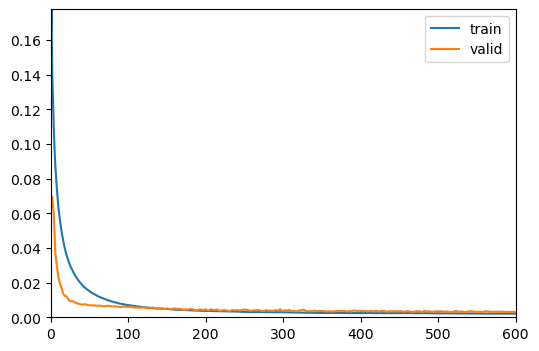

In [18]:
learn.fit_flat_cos(300,lr)

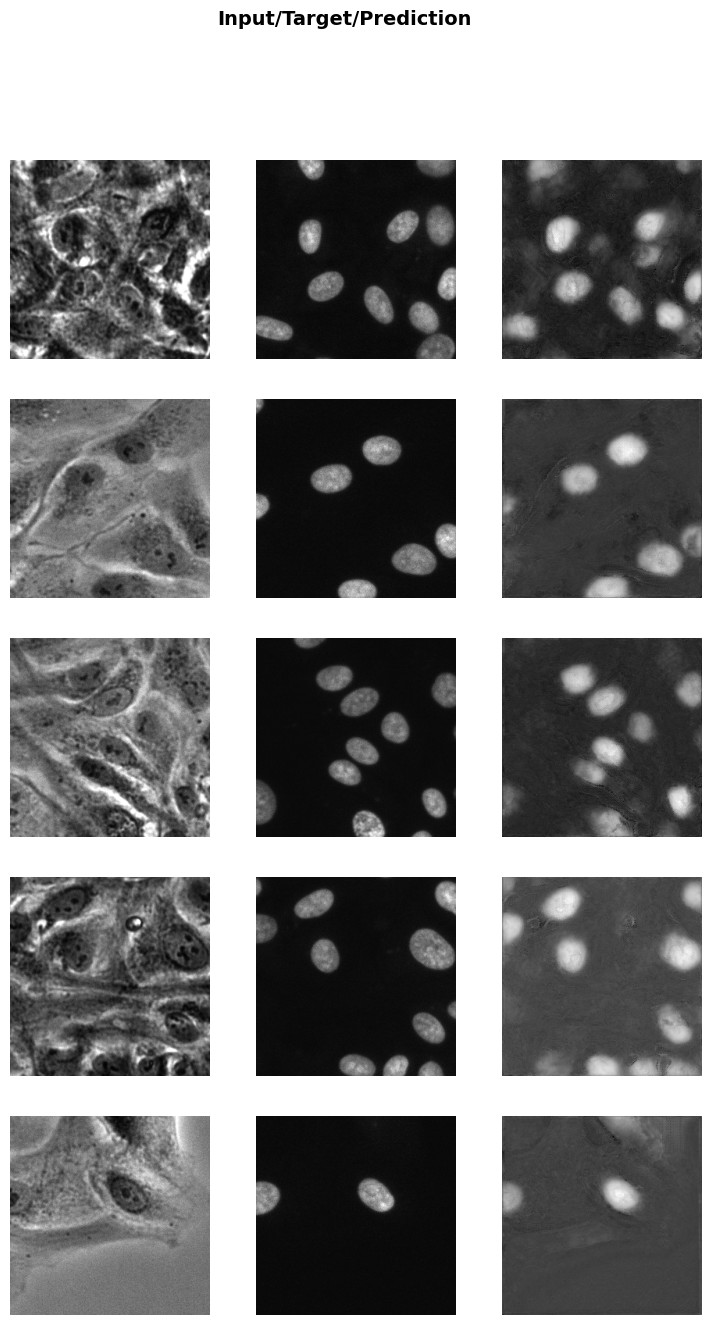

In [19]:
learn.show_results(cmap='gray')

In [32]:
# learn.save('tmp-model')

### Test data 
Evaluate the performance of the selected model on unseen data.
It’s important to not touch this data until you have fine tuned your model to get an unbiased evaluation!

### Export learner

In [33]:
# store_variables(pkl_fn='vars.pkl', size=size, reorder=reorder,  resample=resample)

In [34]:
# learn.export('______.pkl')

In [35]:
#| hide
import nbdev; nbdev.nbdev_export()